## Required packages before use in this order

> *pip install git+https://github.com/amr8004/ESPEI.git* <br>
<br>
> *pip install git+https://github.com/amr8004/pycalphad.git*

In [2]:
import numpy as np
import pandas as pd
import emcee
import matplotlib.pyplot as plt
import pycalphad.model as pype
from espei import pureElement as pe
from pycalphad.model import RWModelE,autoH,CSModelE,SRModelE,autoS,autoG, pe_dict, RTDB_globals, Define_Element
from espei.pureElement import imp_data_PE, log_probability, log_likelihood, Cp_fit, pe_inputJSON,pe_def_model, pe_iGuess
import json
import os

c:\Users\xander\anaconda3\envs\PESPEIv3\lib\site-packages\pydantic\_migration.py:283: UserWarning: `pydantic:PyObject` has been moved to `pydantic.types:ImportString`.
  warnings.warn(f'`{import_path}` has been moved to `{new_location}`.')


In [3]:
os.chdir('C:/Users/xander/Documents/github_repositories/PureElement')
os.getcwd()

'C:\\Users\\xander\\Documents\\github_repositories\\PureElement'

In [4]:

element = 'Hf'
#csvName = r'C:/Users/xander/Documents/github_repositories/PureElement/CpCSV/{element}_CP_data.csv'
csvName = f'CpCSV/{element}_CP_data.csv'
jsonName = f'CpJson/{element}_CP.json'

# Read the CSV and add the data to a dictionary
df=pd.read_csv(csvName, header=[0,0])
header = df.columns.tolist()
data = {}
for col in header:
    column_values = df[col].values.flatten().tolist()
    data[col[0]] = column_values[::]

In [5]:
print(data.keys())
data['Temperature: K']

dict_keys(['Temperature: K', 'Heat capacity at constant pressure Cp: J/K/mol', 'Uncertainty', 'Pressure', 'Ref Temp', 'Data Set ID', 'State', 'Representation', 'Method', 'Description', 'Purity', 'Purity Units', 'Year'])


[14.67,
 20.84,
 22.46,
 24.18,
 27.12,
 31.35,
 34.49,
 35.84,
 36.85,
 38.68,
 40.92,
 43.15,
 45.18,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 90.89,
 94.28,
 97.95,
 101.03,
 104.19,
 106.29,
 109.2,
 195.6,
 198.53,
 199.49,
 200.72,
 202.81,
 205.52,
 207.3,
 209.52,
 213.32,
 13.0,
 20.0,
 30.0,
 40.0,
 50.0,
 nan,
 nan,
 nan,
 90.0,
 100.0,
 110.0,
 200.0,
 210.0,
 20.0,
 1.2,
 1.3,
 1.4,
 1.5,
 1.6,
 1.7,
 1.8,
 1.9,
 2.0,
 2.1,
 2.2,
 2.3,
 2.4,
 2.5,
 2.6,
 2.7,
 2.8,
 2.9,
 3.0,
 3.1,
 3.2,
 3.3,
 3.4,
 3.5,
 3.6,
 3.7,
 3.8,
 3.9,
 4.0,
 20.0,
 11.3,
 12.9,
 14.8,
 17.0,
 18.4,
 19.8,
 20.9,
 23.2,
 24.5,
 26.3,
 27.5,
 28.4,
 29.8,
 31.2,
 32.2,
 33.3,
 34.6,
 35.4,
 36.0,
 37.5,
 38.6,
 39.5,
 40.7,
 42.9,
 44.4,
 45.6,
 47.0,
 48.0,
 49.3,
 50.7,
 55.6,
 57.4,
 59.1,
 61.1,
 63.0,
 64.5,
 66.5,
 68.6,
 70.2,
 72.1,
 74.7,
 76.8,
 79.5,
 83.0,
 84.7,
 88.1,
 90.1,
 91.7,
 93.8,
 94.6,
 10.0,
 15.0,
 20.0,
 25.0,
 30.

In [6]:
if 'Temperature: K' in data:
    data['Temp'] = data.pop('Temperature: K')
else:
    print("Key ['Temperature: K'] does not exist in the data dictionary.")


In [7]:
# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(jsonName), exist_ok=True)

# Open the file
with open(jsonName, 'w') as file:
    json.dump(data, file)

In [8]:

Define_Element([element.upper()])
data=imp_data_PE(jsonName)

In [9]:
# Filter the data to include only points where Temp is 500 or below
filtered_data = {key: np.array(value)[data['Temp'] <= 500] for key, value in data.items()}

# Create a new DataFrame with the filtered data
filtered_df = pd.DataFrame(filtered_data)

# Display the filtered DataFrame
print(filtered_df)

     Heat capacity at constant pressure Cp: J/K/mol  Uncertainty  Pressure  \
0                                           0.25104     0.012552  None kPa   
1                                           0.71128     0.035564  None kPa   
2                                           0.96232     0.048116  None kPa   
3                                           1.08784     0.054392  None kPa   
4                                           1.54808     0.077404  None kPa   
..                                              ...          ...       ...   
222                                         1.03763     0.031129  None kPa   
223                                         1.21754     0.036526  None kPa   
224                                         1.39746     0.041924  None kPa   
225                                         1.61084     0.048325  None kPa   
226                                         1.84514     0.055354  None kPa   

     Ref Temp  Data Set ID  State Representation  \
0         N

In [10]:
# Load data from CSV
#data = pd.read_csv('sr_ipynb/Cr_Cp.txt', sep="\t")

# Extract columns
temp = filtered_df['Temp'].values
cp = filtered_df['Heat capacity at constant pressure Cp: J/K/mol'].values



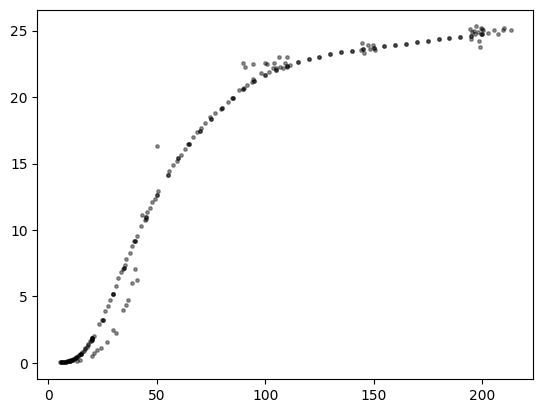

In [11]:
plt.scatter(temp, cp, color='k',s=6, alpha=0.4, label='Data')

In [12]:
# Initial guess for parameters
initial_params = [230, 1e-3, 1e-6]  # You can adjust these initial guesses
#initial_5params = [300, 1e-3, 0.01, 400, 300]
initial_5params = [225, 1e-4, 1e-2, 100, 300]
nobs = len(data['Temp']) 
nparm = len(initial_params)
nparm5 = len(initial_5params)

In [13]:
from espei.pureElement import log_probability

In [14]:
# Number of walkers and number of steps
nwalkers = 12
nsteps = 2000

model_flag='SRModelE'

# Set up the sampler
ndim = len(initial_5params)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(temp, cp, model_flag))

# Initialize walkers
#pos = [initial_5params + 1e-4*np.random.randn(ndim) for _ in range(nwalkers)]
pos = []
for i in range(nwalkers):
    re = []
    std = np.random.randn(len(initial_5params))
    for n,v in enumerate(initial_5params):
        va = v + 0.25*std[n]*v
        re.append(va)
    pos.append(np.array(re))
pos2 = [initial_5params + 1e-4*np.random.randn(ndim) for _ in range(nwalkers)]
# Run the MCMC sampling
sampler.run_mcmc(pos, nsteps, progress=True)


100%|██████████| 2000/2000 [00:25<00:00, 77.90it/s] 


State([[ 1.49822931e+02  5.62975038e-03  4.19860372e-02 -7.28717105e+16
  -7.34993443e+16]
 [ 1.50128418e+02  5.54785171e-03  6.83824654e-02 -3.33890701e+16
  -3.35329759e+16]
 [ 1.48024913e+02  5.95961800e-03  6.33860689e-02  3.90757627e+16
   3.90124268e+16]
 [ 1.56028436e+02  4.06305444e-03  1.97175405e-03  4.73147504e+06
   4.80496649e+06]
 [ 1.48551105e+02  5.70061527e-03  9.60117573e-02  1.24397531e+16
   1.23733379e+16]
 [ 1.50388764e+02  4.86773732e-03  2.54042300e-02 -2.78529850e+17
  -2.79288918e+17]
 [ 1.50688093e+02  6.63764973e-03  7.64492691e-02 -1.08735553e+17
  -1.09001702e+17]
 [ 1.52034312e+02  3.76594583e-03  8.46268177e-02  1.33937843e+05
   1.35276329e+05]
 [ 1.55399916e+02  1.13100928e-05  3.87231888e-03 -1.00285560e+02
  -9.17337095e+01]
 [ 1.58002369e+02  4.04872923e-03  8.29652794e-03  2.32093350e+06
   2.34853782e+06]
 [ 1.49004521e+02  5.33851794e-03  7.89570932e-02  1.09128497e+16
   1.08814641e+16]
 [ 1.46630772e+02  4.48781132e-03  8.60652878e-02 -2.051595

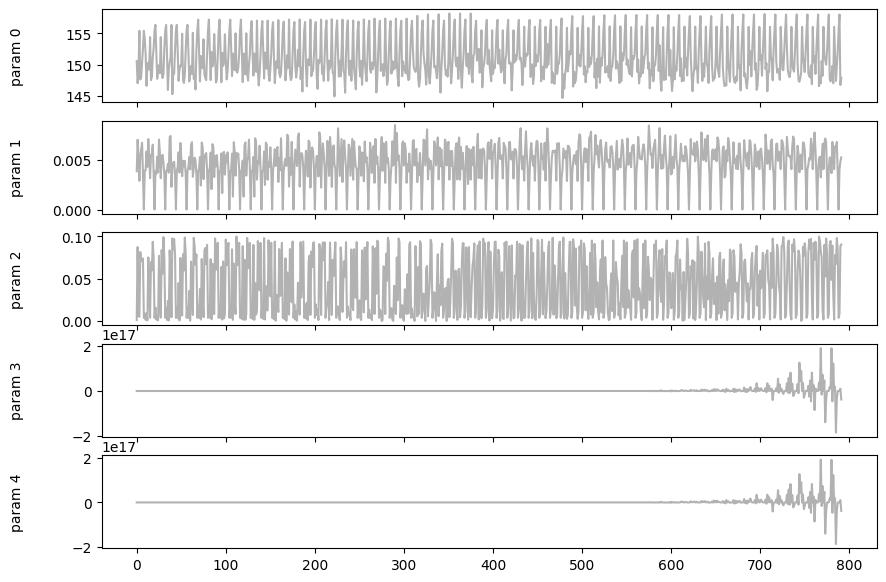

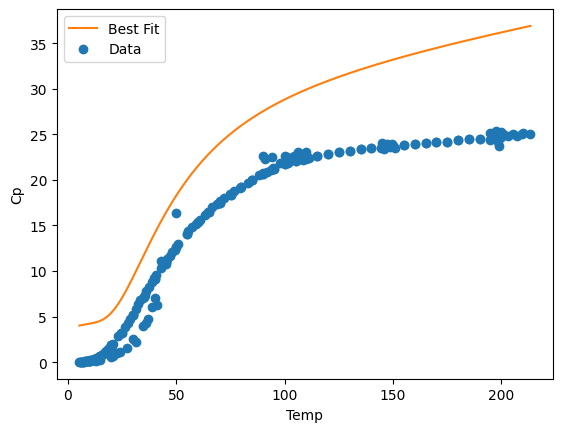

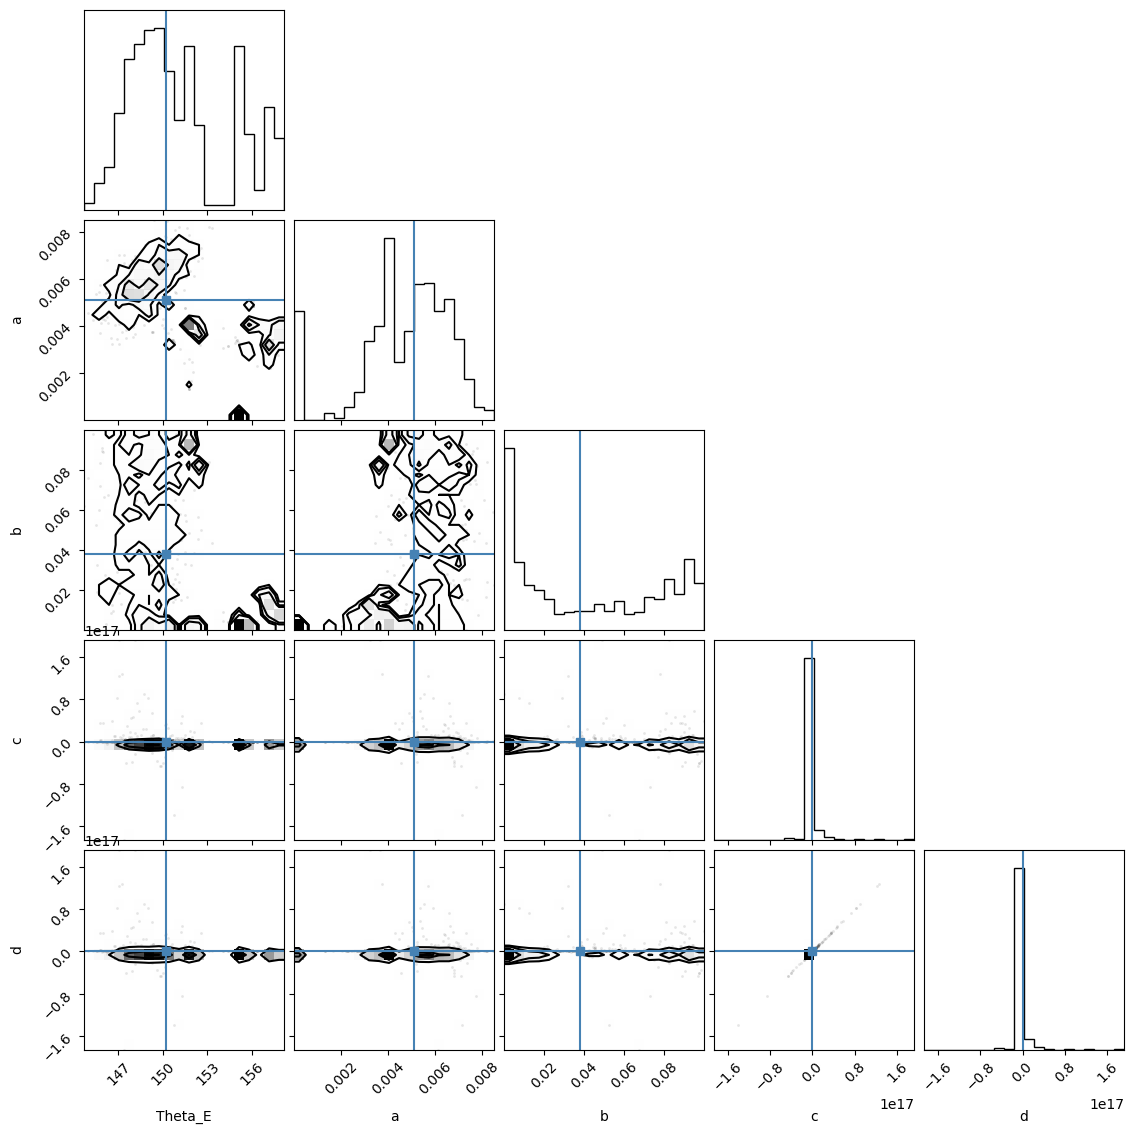

In [15]:
# Extract samples
samples = sampler.get_chain(flat=True, discard=1000, thin=15)
log_prob = sampler.get_log_prob(flat=True, discard=1000, thin=15)

# Plot the chains
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, i], color="k", alpha=0.3)
    ax.set_ylabel(f"param {i}")
    ax.yaxis.set_label_coords(-0.1, 0.5)

# Plot the best-fit curve with uncertainties
best_params = samples[np.argmax(log_prob)]
T_plot = np.linspace(min(temp), max(temp), 1000)
plt.figure()
plt.errorbar(temp, cp, fmt='o', label='Data')
plt.plot(T_plot, SRModelE(T_plot, *best_params), label='Best Fit')
plt.xlabel('Temp')
plt.ylabel('Cp')
plt.legend()
plt.show()

#Corner plot for visualizing parameter distributions
import corner
fig = corner.corner(samples, labels=["Theta_E", "a", "b","c","d"], truths=best_params)
plt.show()


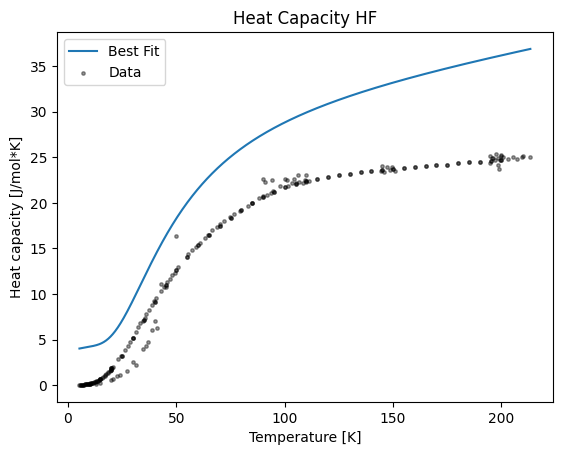

In [16]:
# Plot the best-fit curve with uncertainties
best_params = samples[np.argmax(log_prob)]
T_plot = np.linspace(min(temp), max(temp), 1000)
plt.figure()
plt.plot(T_plot, SRModelE(T_plot, *best_params), label='Best Fit')


plt.scatter(temp, cp, color='k',s=6, alpha=0.4, label='Data')
plt.xlabel("Temperature [K]")
plt.ylabel("Heat capacity [J/mol*K]")
plt.title(f"Heat Capacity {RTDB_globals['element'][0]}")
plt.legend()
plt.show()

In [17]:
from IPython.display import display, Math

for i in range(ndim):
    mcmc = np.percentile(samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.6f}_{{-{1:.10f}}}^{{{2:.10f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], f"param {i}")
    display(Math(txt))
best_params

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

array([ 1.50227624e+02,  5.09172738e-03,  3.78631096e-02, -1.00285560e+02,
       -9.17337095e+01])

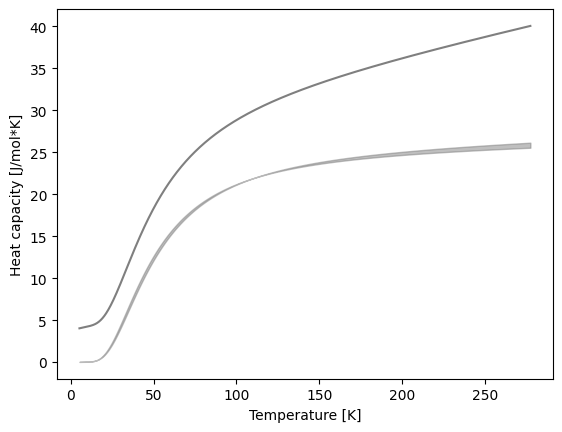

In [18]:
best_params = samples[np.argmax(log_prob)]
mean_params = np.mean(samples, axis=0)
rangeSR=np.percentile(samples, [40, 50, 84], axis=0)
T_plot = np.linspace(min(temp), max(temp)*1.3, 1000)

plt.figure()
#plt.errorbar(temp, cp, fmt='o', label='Data', color = 'grey', alpha = 0.1)
#plt.plot(T_plot, SRModelE(T_plot, *best_params), label='Median', color = 'b')
#plt.plot(T_plot, SRModelE(T_plot, *mean_params), label='Mean', color = 'red')
plt.plot(T_plot, SRModelE(T_plot, *rangeSR[1]), label='50th', color = 'k', alpha = 0.5)
sixteenth=SRModelE(T_plot, *rangeSR[0])
eightyfourth=SRModelE(T_plot, *rangeSR[2])
plt.fill_between(T_plot, sixteenth, eightyfourth, color='grey', alpha=0.5)
plt.plot
plt.xlabel("Temperature [K]")
plt.ylabel("Heat capacity [J/mol*K]")
#plt.legend()
plt.show()

In [19]:
s1 = np.std(samples[:,0], ddof=1)
s2 = np.std(samples[:,1], ddof=1)
s3 = np.std(samples[:,2], ddof=1)
s4 = np.std(samples[:,3], ddof=1)
s5 = np.std(samples[:,4], ddof=1)

In [20]:
print('Standard deviation of Theta_E:', s1)
print('Standard deviation of a:', s2)
print('Standard deviation of b:', s3)
print('Standard deviation of c:', s4)
print('Standard deviation of d:', s5)

Standard deviation of Theta_E: 3.3994548656731203
Standard deviation of a: 0.001934209826243248
Standard deviation of b: 0.03538733476171528
Standard deviation of c: 1.7130052568081648e+16
Standard deviation of d: 1.7134408598725924e+16


In [21]:
# Number of walkers and number of steps
nwalkers = 32
nsteps = 1000

model_flag='CSModelE'

# Set up the sampler
ndim = len(initial_params)
sampler2 = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(temp, cp, model_flag))

# Initialize walkers
#pos = [initial_params + 1e-4*np.random.randn(ndim) for _ in range(nwalkers)]
pos = []
for i in range(nwalkers):
    re = []
    std = np.random.randn(len(initial_params))
    for n,v in enumerate(initial_params):
        va = v + 0.25*std[n]*v
        re.append(va)
    pos.append(np.array(re))
# Run the MCMC sampling
sampler2.run_mcmc(pos, nsteps)


State([[1.47241118e+02 5.40379725e-03 1.82791166e-11]
 [1.45329798e+02 4.67028322e-03 8.77299914e-11]
 [1.49193085e+02 6.06343524e-03 6.13295536e-11]
 [1.47561415e+02 4.32210359e-03 1.11011935e-10]
 [1.49110869e+02 6.04258409e-03 5.02155413e-11]
 [1.47731912e+02 4.92612946e-03 1.25466865e-10]
 [1.50860662e+02 6.81310885e-03 1.37856661e-10]
 [1.48806663e+02 5.70820826e-03 2.76174581e-12]
 [1.47819857e+02 5.71026981e-03 7.47782713e-11]
 [1.49538260e+02 5.13240231e-03 6.92579588e-11]
 [1.50428919e+02 5.76746208e-03 1.75670547e-11]
 [1.48822978e+02 4.86533121e-03 5.72763459e-11]
 [1.47825141e+02 5.96335074e-03 6.18785915e-11]
 [1.47035123e+02 5.92755716e-03 1.11680054e-11]
 [1.49109086e+02 5.32315049e-03 8.72259497e-11]
 [1.49866219e+02 7.23032623e-03 6.21883389e-12]
 [1.47653839e+02 4.86305431e-03 1.65300103e-11]
 [1.48463121e+02 5.05131566e-03 1.21428370e-11]
 [1.49082393e+02 4.90880617e-03 1.03891402e-10]
 [1.48644182e+02 5.31350154e-03 7.91829342e-11]
 [1.49886212e+02 5.60687118e-03 2.

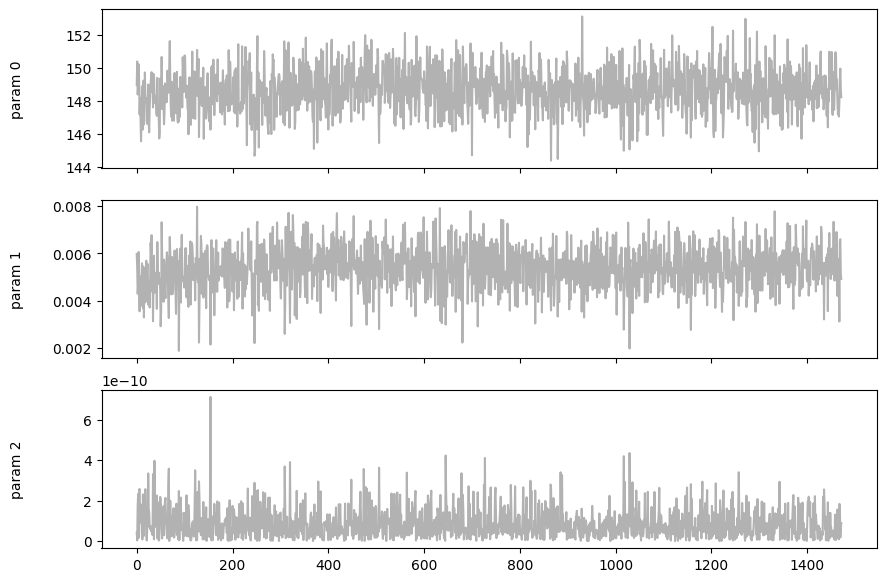

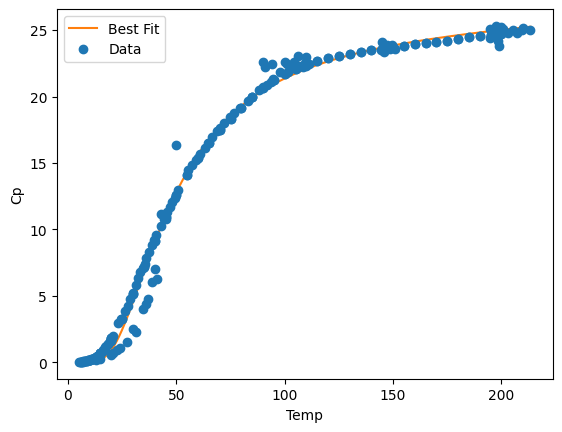

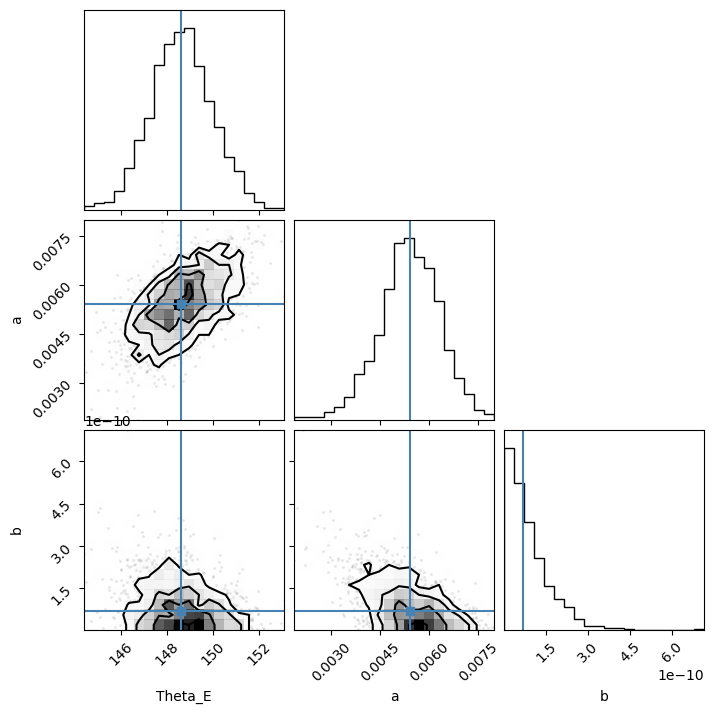

In [22]:
# Extract samples
samples2 = sampler2.get_chain(discard=300, thin=15, flat=True)
log_prob2 = sampler2.get_log_prob(flat=True, discard=300, thin=15)

# Plot the chains
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples2[:, i], color="k", alpha=0.3)
    ax.set_ylabel(f"param {i}")
    ax.yaxis.set_label_coords(-0.1, 0.5)

# Plot the best-fit curve with uncertainties
best_params2 = samples2[np.argmax(log_prob2)]
T_plot = np.linspace(min(temp), max(temp), 1000)
plt.figure()
plt.errorbar(temp, cp, fmt='o', label='Data')
plt.plot(T_plot, CSModelE(T_plot, *best_params2), label='Best Fit')
plt.xlabel('Temp')
plt.ylabel('Cp')
plt.legend()
plt.show()

#Corner plot for visualizing parameter distributions
import corner
fig = corner.corner(samples2, labels=["Theta_E", "a", "b"], truths=best_params2)
plt.show()


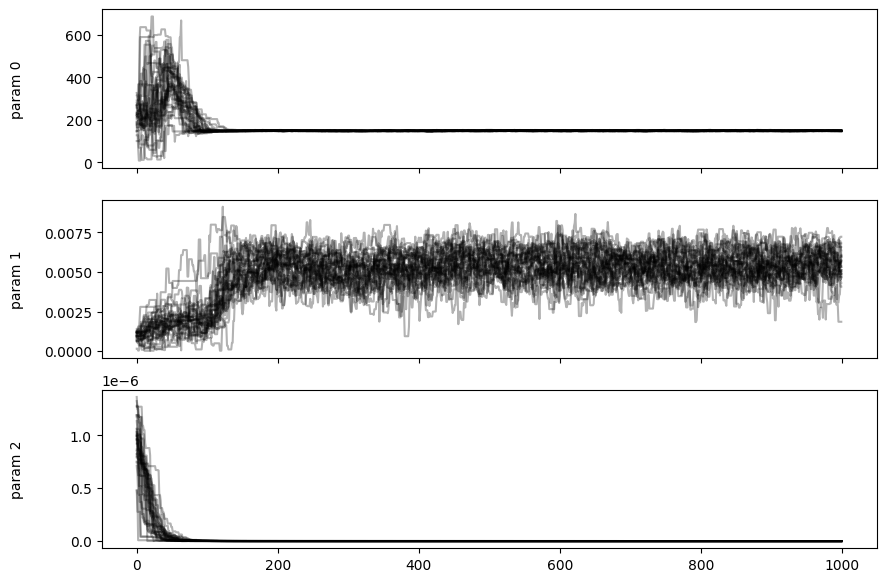

In [23]:
unflat2=sampler2.get_chain()
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(unflat2[:,:,i], color="k", alpha=0.3)
    ax.set_ylabel(f"param {i}")
    ax.yaxis.set_label_coords(-0.1, 0.5)

In [24]:
from IPython.display import display, Math

for i in range(ndim):
    mcmc = np.percentile(samples2[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.14f}_{{-{1:.10f}}}^{{{2:.10f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], f"param {i}")
    display(Math(txt))
best_params2

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

array([1.48631499e+02, 5.40322056e-03, 6.78319782e-11])

In [25]:
# Number of walkers and number of steps
nwalkers = 32
nsteps = 2000

model_flag='RWModelE'

# Set up the sampler
ndim = len(initial_params)
sampler3 = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(temp, cp, model_flag))

# Initialize walkers
#pos = [initial_params + 1e-4*np.random.randn(ndim) for _ in range(nwalkers)]
pos = []
for i in range(nwalkers):
    re = []
    std = np.random.randn(len(initial_params))
    for n,v in enumerate(initial_params):
        va = v + 0.25*std[n]*v
        re.append(va)
    pos.append(np.array(re))
# Run the MCMC sampling
sampler3.run_mcmc(pos, nsteps)


State([[1.48409955e+02 3.74855751e-03 9.97243359e-06]
 [1.50417605e+02 5.85598109e-03 2.67673648e-07]
 [1.47894229e+02 4.26698484e-03 1.71331369e-06]
 [1.49287346e+02 4.64757991e-03 9.23653862e-06]
 [1.48197428e+02 3.53055915e-03 6.04834745e-06]
 [1.50822983e+02 5.75127751e-03 2.96733905e-07]
 [1.48446348e+02 5.54748535e-03 1.30223285e-06]
 [1.49412007e+02 6.97787528e-03 2.09305026e-07]
 [1.49853026e+02 5.40682426e-03 3.27484478e-06]
 [1.46742595e+02 4.30323765e-03 8.03161989e-06]
 [1.47419257e+02 5.33374250e-03 8.48233556e-07]
 [1.48981203e+02 4.96003738e-03 8.12364525e-06]
 [1.50775599e+02 6.06774649e-03 1.49988080e-06]
 [1.47759218e+02 5.55194982e-03 2.44248876e-06]
 [1.47587506e+02 5.05072171e-03 9.33533242e-06]
 [1.47286226e+02 5.89613412e-03 2.94361566e-06]
 [1.49197882e+02 3.97709195e-03 1.03095073e-05]
 [1.48411081e+02 5.35966523e-03 6.78298389e-07]
 [1.46570308e+02 3.96324727e-03 1.25773473e-05]
 [1.50381099e+02 6.86484860e-03 2.40941082e-06]
 [1.48254332e+02 5.65494148e-03 4.

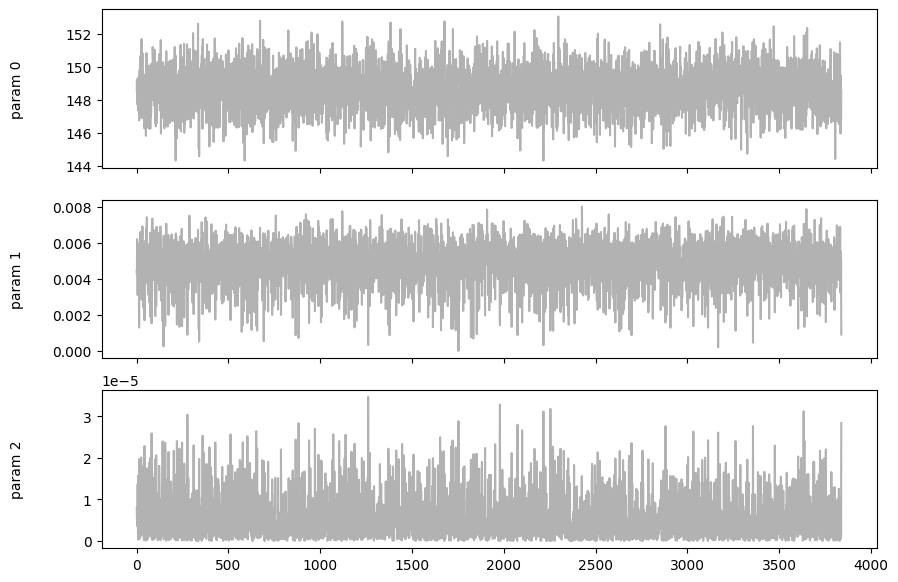

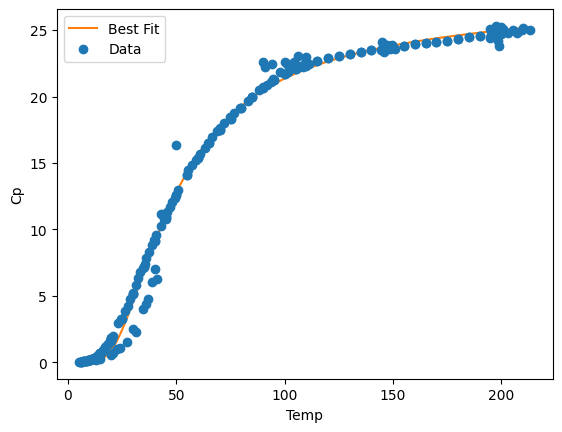

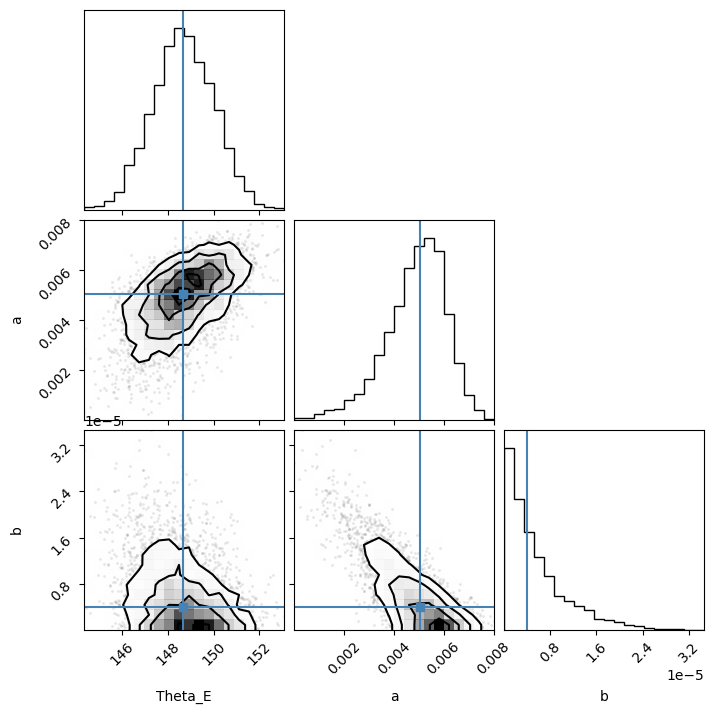

In [26]:
# Extract samples
samples3 = sampler3.get_chain(discard=200, thin=15, flat=True)
log_prob3 = sampler3.get_log_prob(flat=True, discard=200, thin=15)

# Plot the chains
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples3[:, i], color="k", alpha=0.3)
    ax.set_ylabel(f"param {i}")
    ax.yaxis.set_label_coords(-0.1, 0.5)

# Plot the best-fit curve with uncertainties
best_params3 = samples3[np.argmax(log_prob3)]
T_plot = np.linspace(min(temp), max(temp), 1000)
plt.figure()
plt.errorbar(temp, cp, fmt='o', label='Data')
plt.plot(T_plot, RWModelE(T_plot, *best_params3), label='Best Fit')
plt.xlabel('Temp')
plt.ylabel('Cp')
plt.legend()
plt.show()

#Corner plot for visualizing parameter distributions
import corner
fig = corner.corner(samples3, labels=["Theta_E", "a", "b"], truths=best_params3)
plt.show()


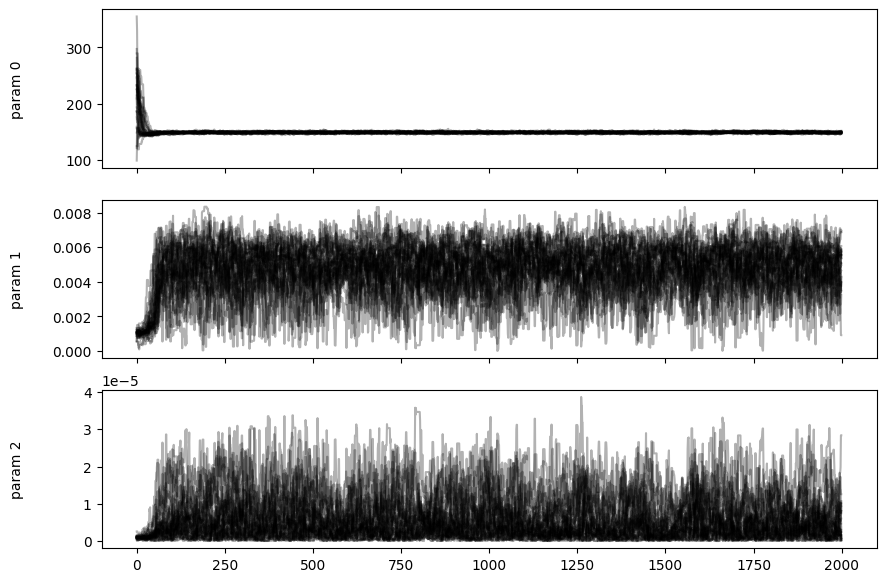

In [27]:
unflat2=sampler3.get_chain()
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(unflat2[:,:,i], color="k", alpha=0.3)
    ax.set_ylabel(f"param {i}")
    ax.yaxis.set_label_coords(-0.1, 0.5)

In [28]:
from IPython.display import display, Math

for i in range(ndim):
    mcmc = np.percentile(samples3[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.6f}_{{-{1:.10f}}}^{{{2:.10f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], f"param {i}")
    display(Math(txt))
print(best_params3)
for i in range(ndim):
    mcmc = np.percentile(samples2[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.6f}_{{-{1:.10f}}}^{{{2:.10f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], f"param {i}")
    display(Math(txt))
print(best_params2)
for i in range(ndim):
    mcmc = np.percentile(samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.6f}_{{-{1:.10f}}}^{{{2:.10f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], f"param {i}")
    display(Math(txt))
print(best_params)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

[1.48657339e+02 5.03549746e-03 3.90497585e-06]


<IPython.core.display.Math object>

...

[1.48631499e+02 5.40322056e-03 6.78319782e-11]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

[ 1.50227624e+02  5.09172738e-03  3.78631096e-02 -1.00285560e+02
 -9.17337095e+01]


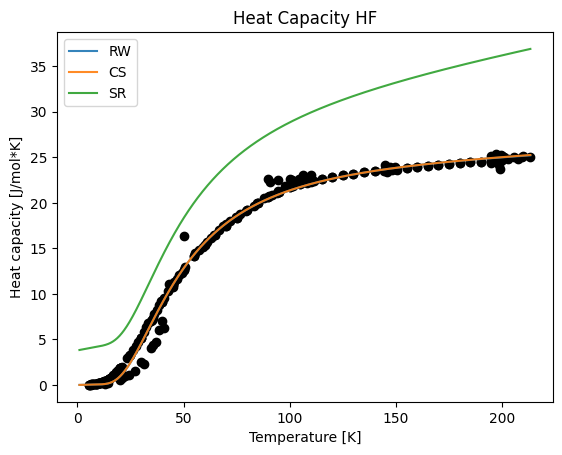

In [29]:
best_params3 = samples3[np.argmax(log_prob3)]
T_plot = np.linspace(1, max(temp), 1000)
plt.figure()
plt.plot(T_plot, RWModelE(T_plot, *best_params3), label='RW', alpha=0.9)
plt.plot(T_plot, CSModelE(T_plot, *best_params2), label='CS', alpha=0.9)
plt.plot(T_plot, SRModelE(T_plot, *best_params), label='SR', alpha=0.9)

plt.scatter(temp, cp, color='k')#,s=6, alpha=0.4, label='Data')
plt.xlabel("Temperature [K]")
plt.ylabel("Heat capacity [J/mol*K]")
plt.title(f"Heat Capacity {RTDB_globals['element'][0]}")
plt.legend()
#plt.gca().set_aspect(30)
#plt.xlim(0,200)
#plt.ylim(0,50)
plt.show()

In [30]:
RW=(RWModelE(T_plot, *best_params3))*(6.022e23)*(1.380649e-23)
CS=(CSModelE(T_plot, *best_params2))*(6.022e23)*(1.380649e-23)
SR=(np.array(SRModelE(T_plot, *best_params)))*(6.022e23)*(1.380649e-23)
cp2=(cp)*(6.022e23)*(1.380649e-23)

In [31]:
print(RW[0],CS[0],SR[0])

0.041898943821077485 0.044923825854063376 31.927438582786127


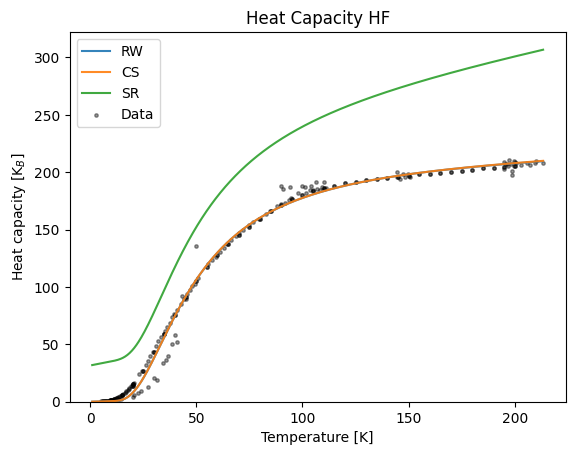

In [32]:
plt.figure()
plt.plot(T_plot, RW, label='RW', alpha=0.9)
plt.plot(T_plot, CS, label='CS', alpha=0.9)
plt.plot(T_plot, SR, label='SR', alpha=0.9)

plt.scatter(temp, cp2, color='k',s=6, alpha=0.4, label='Data')
plt.xlabel("Temperature [K]")
plt.ylabel("Heat capacity [K$_{B}$]")
plt.title(f"Heat Capacity {RTDB_globals['element'][0]}")
plt.legend()
#plt.xlim(300,900)
plt.ylim(0)
plt.show()

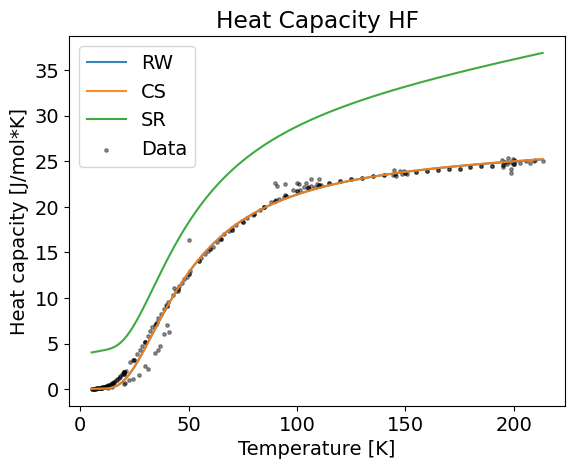

In [33]:
plt.rcParams.update({'font.size': 14})
best_params3 = samples3[np.argmax(log_prob3)]
T_plot = np.linspace(min(temp), max(temp), 1000)
plt.figure()
plt.plot(T_plot, RWModelE(T_plot, *best_params3), label='RW', alpha=0.9)
plt.plot(T_plot, CSModelE(T_plot, *best_params2), label='CS', alpha=0.9)
plt.plot(T_plot, SRModelE(T_plot, *best_params), label='SR', alpha=0.9)

plt.scatter(temp, cp, color='k',s=6, alpha=0.4, label='Data')
plt.xlabel("Temperature [K]")
plt.ylabel("Heat capacity [J/mol*K]")
plt.title(f"Heat Capacity {RTDB_globals['element'][0]}")
plt.legend()
plt.show()

c:\Users\xander\anaconda3\envs\PESPEIv3\lib\site-packages\pycalphad\io\tdb.py:925: UserWarning: The type definition character `I` was defined in the following phases: ['CBCC_A12', 'BCC_A2', 'FCC_A1', 'HCP_A3'], but no corresponding TYPE_DEFINITION line was found in the TDB.
  warnings.warn(f"The type definition character `{typechar}` was defined in the following phases: "


-258.3073879927794 <class 'numpy.ndarray'> 200
0.005037449948959384 <class 'numpy.ndarray'> 200
sr


c:\Users\xander\anaconda3\envs\PESPEIv3\lib\site-packages\pycalphad\model.py:1956: RuntimeWarning: invalid value encountered in log
  S = (-3.0*k2*alfa/2 - k2/(4.0*g)*((alfa-g)**2 * np.log(alfa-g)-(alfa+g)**2*np.log(alfa+g)))*x+(k1+k2)*x**2-k2*alfa*x*np.log(x)


Text(0.5, 1.0, 'Gibbs HF')

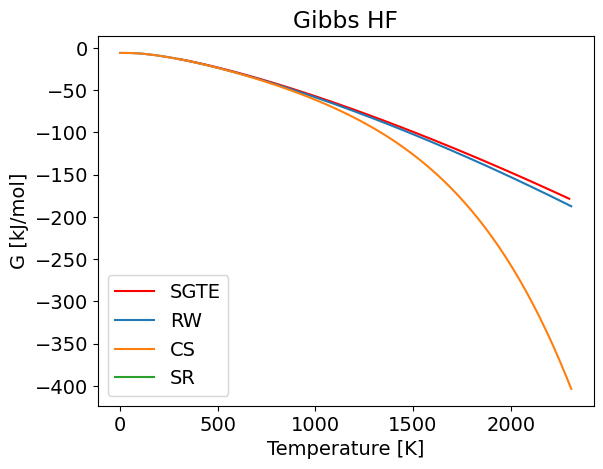

In [34]:
CSa=best_params2[1]
CSb=best_params2[2]
CSE=best_params2[0]

RWE = best_params3[0]
RWa=best_params3[1]
RWb=best_params3[2]

RTDB_globals['Te_final'] = best_params[0]
RTDB_globals['k1_final'] = best_params[1]
RTDB_globals['k2_final'] = best_params[2]
RTDB_globals['alfa_final'] = best_params[3]
RTDB_globals['g_final'] = best_params[4]
from pycalphad import Database, calculate, equilibrium, variables as v
db_sgte = Database('sgte-unary.tdb')
T_range = np.linspace(1,data.Temp.max()*1.1,num=200)
fcc_GM = calculate(db_sgte, [element.upper(), 'VA'], 'HCP_A3', P=101325, T=(300, max(T_range), 10), N=1)
plt.plot(fcc_GM.T, fcc_GM.GM.squeeze()/1000, label='SGTE', color = 'r')
GRW=pype.GTRWM(T_range,RWa,RWb)
GRW1=GRW+pype.GEin(RWE,T_range)
plt.plot(T_range,GRW1/1000,label='RW')
GCStest=pype.GTCSM(T_range,CSa,CSb)
GCS1=GCStest+pype.GEin(CSE,T_range)
plt.plot(T_range,GCS1/1000,label='CS')
GSR=autoG(T_range,'SRModelE')
GSRtest=pype.GEin(RTDB_globals['Te_final'],T_range)+pype.GTBCM(T_range,RTDB_globals['k1_final'],RTDB_globals['k2_final'],RTDB_globals['alfa_final'],RTDB_globals['g_final'])#+pype.GibbsM_Bosse(T_range)
plt.plot(T_range,GSRtest/1000, label = 'SR')
plt.xlabel("Temperature [K]")
plt.ylabel("G [kJ/mol]")
plt.legend()
plt.title(f"Gibbs {RTDB_globals['element'][0]}")

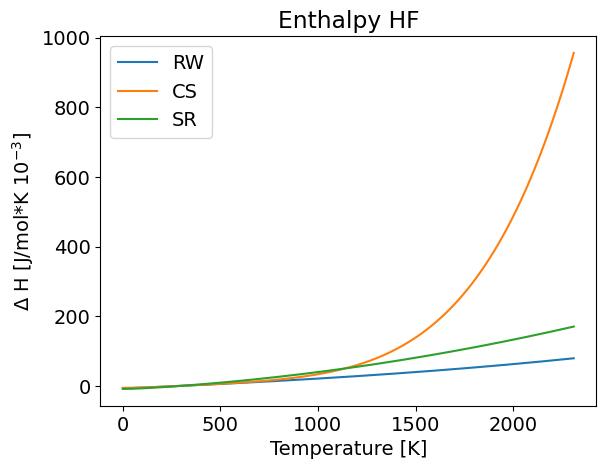

In [35]:
HCS298=pype.HTCSM(298.15,CSa,CSb)+pype.HEin(CSE,298.15)#+pype.HM(T_range)[29]
HSR298=pype.HTBCM(298.15,RTDB_globals['k1_final'], RTDB_globals['k2_final'], RTDB_globals['alfa_final'], RTDB_globals['g_final'])+pype.HEin(RTDB_globals['Te_final'],298.15)#+pype.HM(T_range)[149]
HRW298=pype.HTRWM(298.15,RWa,RWb)+pype.HEin(RWE,298.15)#+pype.HM(T_range)[149]
HCS=pype.HTCSM(T_range,CSa,CSb)+pype.HEin(CSE,T_range)#+pype.HM(T_range)
HCS2=HCS-HCS298
HSR2=pype.HTBCM(T_range,RTDB_globals['k1_final'], RTDB_globals['k2_final'], RTDB_globals['alfa_final'], RTDB_globals['g_final'])+pype.HEin(RTDB_globals['Te_final'],T_range)#+pype.HM(T_range)
HSR=HSR2-HSR298
HRW2=pype.HTRWM(T_range,RWa,RWb)+pype.HEin(RWE,T_range)#+pype.HM(T_range)
HRW=HRW2-HRW298
plt.plot(T_range,10**-3*HRW,label='RW')
plt.plot(T_range,10**-3*HCS2,label='CS')
plt.plot(T_range,10**-3*HSR,label='SR')
plt.xlabel("Temperature [K]")
plt.ylabel(r'$\Delta$ H [J/mol*K $10^{-3}$]')
plt.title("H_Ein+H_BCM-H298.15")
plt.title(f"Enthalpy {RTDB_globals['element'][0]}")
plt.legend()

c:\Users\xander\anaconda3\envs\PESPEIv3\lib\site-packages\pycalphad\model.py:1938: RuntimeWarning: invalid value encountered in log
  Si = (-3.0*k2*alfa/2 - k2/(4.0*g)*((alfa-g)**2 * np.log(alfa-g)-(alfa+g)**2*np.log(alfa+g)))+(k1+k2)*i-k2*alfa*np.log(i)


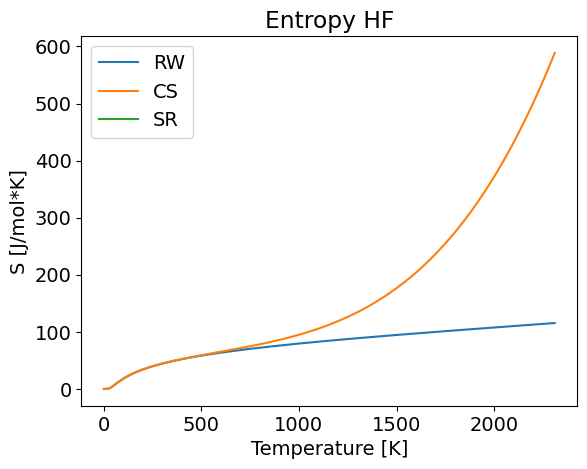

In [36]:
SE1=pype.SEin(RTDB_globals['Te_final'],T_range)
SBCM1=pype.STBCM(T_range, RTDB_globals['k1_final'], RTDB_globals['k2_final'], RTDB_globals['alfa_final'], RTDB_globals['g_final'])
#Smag=pype.SM(T_range)
Scomb=SBCM1+SE1#+Smag
SRW=pype.STRWM(T_range,RWa,RWb)+pype.SEin(RWE,T_range)#+Smag
SCS=pype.STCSM(T_range,CSa,CSb)+pype.SEin(CSE,T_range)#+Smag
plt.plot(T_range,SRW,label = 'RW')
plt.plot(T_range,SCS,label = 'CS')
plt.plot(T_range,Scomb,label = 'SR')
plt.xlabel("Temperature [K]")
plt.ylabel("S [J/mol*K]")
plt.title(f"Entropy {RTDB_globals['element'][0]}")
plt.legend()

In [37]:
def PE_AICC(nparm, nobs,logLik,aicc_factor=None, kk=2):
    #print('CHECKPOINT AICC CALLED')
    k= nparm
    n = nobs
    AIC = -2 * logLik + kk *(k+1)
    print('k=',k,
    'n=',n)
    p=aicc_factor if aicc_factor is not None else 1.0
    pk = nparm*p
    aic = -2*logLik+2*(nparm+1)
    print('aic2:', aic)
    if pk >= (n-1.0):
        # Prevent the denominator of the proper mAICc from blowing up (pk = n - 1) or negative (pk > n - 1)
        correction = (2.0* p**2 * k**2 + 2.0 * pk) * (-n + pk + 3.0)
    else:
        correction = (2.0 * p**2 * k**2 + 2.0 * pk) / (n - pk - 1.0)
    aicc = aic+correction
    print('correction: ',correction)
    #print('CHECKPOINT AICC SOLVED')
    return aicc

nobs = len(data['Temp']) 
nparm = len(initial_params)
nparm5 = len(initial_5params)

In [38]:
RW_logLik = log_likelihood(best_params3,temp,cp,'RWModelE')
AICC_RW=PE_AICC(nparm,nobs,RW_logLik)

CS_logLik = log_likelihood(best_params2,temp,cp,'CSModelE')
AICC_CS=PE_AICC(nparm,nobs,CS_logLik)

SR_logLik = log_likelihood(best_params,temp,cp,'SRModelE')
AICC_SR=PE_AICC(nparm5,nobs,SR_logLik)

k= 3 n= 254
aic2: 128.7620597234764
correction:  0.096
k= 3 n= 254
aic2: 128.88753198267355
correction:  0.096
k= 5 n= 254
aic2: 11530.06437577432
correction:  0.24193548387096775


In [39]:
print('AICC_RW:', AICC_RW)
print('AICC_CS:', AICC_CS)
print('AICC_SR:', AICC_SR)

AICC_RW: 128.8580597234764
AICC_CS: 128.98353198267355
AICC_SR: 11530.306311258191


In [40]:
output_file='41_Elements/HCP/Results/'+element+'_output.json'
params={'CS':best_params2.tolist(),'RW':best_params3.tolist(),'SR':best_params.tolist(),'AICC_RW':AICC_RW,'AICC_CS':AICC_CS,'AICC_SR':AICC_SR}
with open(output_file, 'w') as f:
    json.dump(params, f, indent=4)